# Basic Numerical Methods


## 1. Least Squares Method and Regression Analysis



### a. Least Squares Method

The least squares method minimizes the sum of squared differences between observed and predicted values. It's used to find the best-fitting line in regression analysis.

Mathematically:
$$
	{Error} = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$
Where:
$$
(y_i) = actual value
$$
$$
(\hat{y}_i) = predicted value$$
$$
    


### b. Simple Linear Regression Example

Goal of Linear Regression:

We want to find the best-fitting line: \( y = mx + b \)

Design Matrix A:
 [[1. 1.]
 [2. 1.]
 [3. 1.]
 [4. 1.]
 [5. 1.]]
Slope (m): 0.7500000000000004
Intercept (b): 1.3899999999999983
Residuals: [0.027]
Rank of matrix A: 2
Singular values of A: [7.69121313 0.91936964]


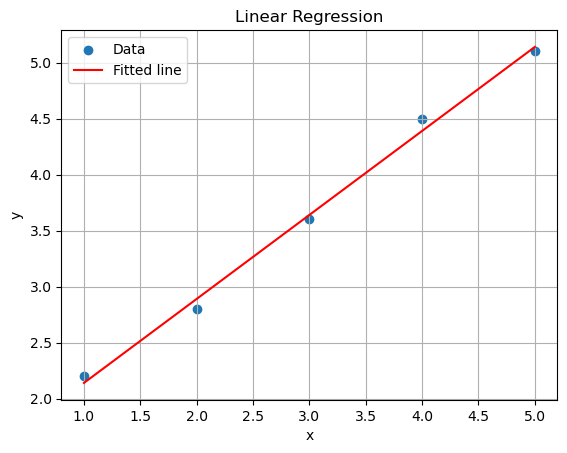

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Design matrix construction based on data points
x = np.array([1, 2, 3, 4, 5])
y = np.array([2.2,2.8,3.6,4.5,5.1])

# Step 2: Build matrix A: Each row represents the linear model y=mx+c.
A = np.vstack([x, np.ones(len(x))]).T # Stack x and a column of ones and then transpose it
print ("Design Matrix A:\n", A) # The first column is the value of x. The second column is always 1, which allows us to solve for the intercept c.

# Step 3: Fit line using least squares- it solves for the slope m and intercept c of the best-fit line
# np.linalg.lstsq returns a tuple (coeffs, residuals, rank, s), so unpack accordingly.
coeffs, residuals, rank, s = np.linalg.lstsq(A, y, rcond=None)
m = coeffs[0]
b = coeffs[1]

# Step 4: Output the results and plot them
print("Slope (m):", m)
print("Intercept (b):", b)
print("Residuals:", residuals)
print("Rank of matrix A:", rank)
print("Singular values of A:", s) 

plt.scatter(x, y, label='Data')
plt.plot(x, m*x + b, 'r', label='Fitted line')
plt.legend()
plt.title('Linear Regression')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.show()


#### Exercise- Make up a set of data and find their best fit using least squares linear regression.

Design Matrix A:
 [[5. 1.]
 [8. 1.]
 [6. 1.]
 [9. 1.]
 [5. 1.]]
Slope (m): -0.8318181818181831
Intercept (b): 10.650000000000015
Residuals: [19.11863636]
Rank of matrix A: 2
Singular values of A: [15.35317579  0.52914384]


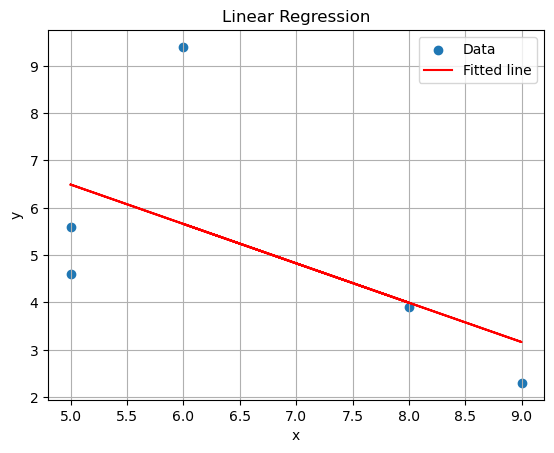

In [2]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([5, 8, 6, 9, 5])
y = np.array([4.6,3.9,9.4,2.3,5.6])

A = np.vstack([x, np.ones(len(x))]).T 
print ("Design Matrix A:\n", A) 

coeffs, residuals, rank, s = np.linalg.lstsq(A, y, rcond=None)
m = coeffs[0]
b = coeffs[1]

print("Slope (m):", m)
print("Intercept (b):", b)
print("Residuals:", residuals)
print("Rank of matrix A:", rank)
print("Singular values of A:", s) 

plt.scatter(x, y, label='Data')
plt.plot(x, m*x + b, 'r', label='Fitted line')
plt.legend()
plt.title('Linear Regression')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.show()


## 2. Root Finding Methods in Numerical Analysis

This notebook demonstrates two popular numerical methods for finding roots of equations:

1. **Bisection Method**
2. **Newton-Raphson Method**

We will use the function:
\[ f(x) = x^3 - 2x - 5 \]



### a. Bisection Method

The Bisection Method is a simple and robust technique for finding roots of a continuous function. It works by repeatedly halving an interval and selecting the subinterval in which the function changes sign.

#### Algorithm Steps:
1. Define the function f(x)
2. Choose interval [a, b] where f(a) * f(b) < 0
3. Repeat until convergence:
   - Compute midpoint c = (a + b)/2
   - Evaluate f(c)
   - If f(c) * f(a) < 0, set b = c
   - Else, set a = c
   - Stop when |f(c)| is small enough


Root found using Bisection Method: 2.0945520401000977


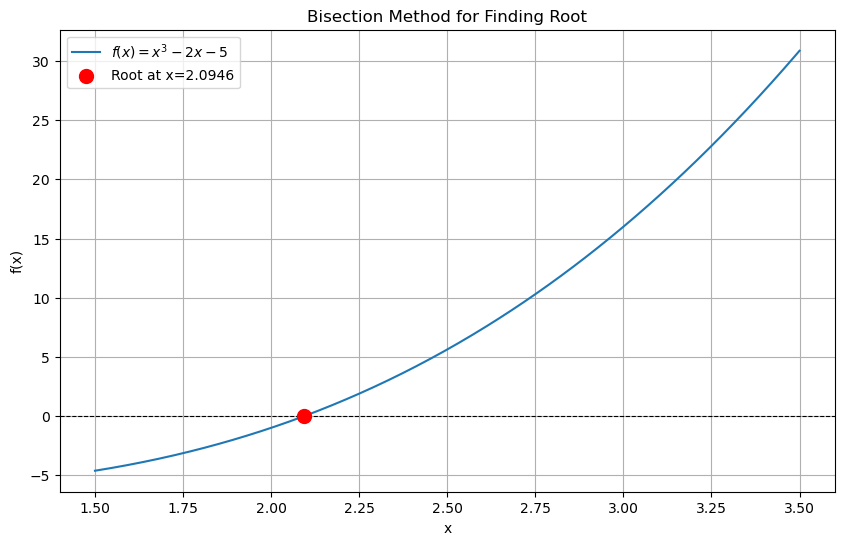

In [5]:
# Complete the Bisection Method implementation
def f(x):
    return x**3 - 2*x - 5
def bisection_method(func, a, b, tol=1e-6, max_iter=100):
    if func(a) * func(b) >= 0:
        print("Bisection method requires f(a) and f(b) to have opposite signs.")
        return None

    for i in range(max_iter):
        c = (a + b) / 2
        if func(c) == 0 or abs(b - a) / 2 < tol:
            return c
        elif func(c) * func(a) < 0:
            b = c
        else:
            a = c
    print("Maximum iterations reached without achieving desired tolerance.")
    return (a + b) / 2

a = 2
b = 3
root_bisection = bisection_method(f, a, b)

if root_bisection is not None:
    print(f"Root found using Bisection Method: {root_bisection}")

    # Plotting the function and the root
    x_vals = np.linspace(1.5, 3.5, 400)
    y_vals = f(x_vals)

    plt.figure(figsize=(10, 6))
    plt.plot(x_vals, y_vals, label=r'$f(x) = x^3 - 2x - 5$')
    plt.axhline(0, color='black', linestyle='--', linewidth=0.8) # x-axis
    plt.scatter(root_bisection, f(root_bisection), color='red', marker='o', s=100, zorder=5, label=f'Root at x={root_bisection:.4f}')
    plt.title('Bisection Method for Finding Root')
    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.grid(True)
    plt.legend()
    plt.show()

# print("Root found using Bisection Method:", root_bisection)
# Your code to plot the function and the root found


In [2]:
# 1. Define the function
def f(x):
    
    return x**3 + 2*x - 5

def bisection_method(a, b, tolerance=1e-6, max_iterations=100):
    
    if f(a) * f(b) >= 0:
        raise ValueError("The function must have opposite signs at the interval endpoints [a, b].")

    for iteration in range(max_iterations):
        c = (a + b) / 2
        f_c = f(c)

        print(f"Iteration {iteration + 1}: a={a:.6f}, b={b:.6f}, c={c:.6f}, f(c)={f_c:.6f}")

        if abs(f_c) < tolerance:
            print(f"\nConverged to root at x = {c:.6f} with |f(x)| < {tolerance}.")
            return c

        if f(a) * f_c < 0:
            b = c
        else:
            a = c

    raise RuntimeError(f"Maximum number of iterations ({max_iterations}) reached without convergence.")

if __name__ == "__main__":
   
    a_initial = 1.0
    b_initial = 2.0

    try:
        root = bisection_method(a_initial, b_initial)
        print(f"The approximate root is: {root:.6f}")
    except (ValueError, RuntimeError) as e:
        print(e)


Iteration 1: a=1.000000, b=2.000000, c=1.500000, f(c)=1.375000
Iteration 2: a=1.000000, b=1.500000, c=1.250000, f(c)=-0.546875
Iteration 3: a=1.250000, b=1.500000, c=1.375000, f(c)=0.349609
Iteration 4: a=1.250000, b=1.375000, c=1.312500, f(c)=-0.114014
Iteration 5: a=1.312500, b=1.375000, c=1.343750, f(c)=0.113861
Iteration 6: a=1.312500, b=1.343750, c=1.328125, f(c)=-0.001049
Iteration 7: a=1.328125, b=1.343750, c=1.335938, f(c)=0.056161
Iteration 8: a=1.328125, b=1.335938, c=1.332031, f(c)=0.027495
Iteration 9: a=1.328125, b=1.332031, c=1.330078, f(c)=0.013208
Iteration 10: a=1.328125, b=1.330078, c=1.329102, f(c)=0.006076
Iteration 11: a=1.328125, b=1.329102, c=1.328613, f(c)=0.002512
Iteration 12: a=1.328125, b=1.328613, c=1.328369, f(c)=0.000731
Iteration 13: a=1.328125, b=1.328369, c=1.328247, f(c)=-0.000159
Iteration 14: a=1.328247, b=1.328369, c=1.328308, f(c)=0.000286
Iteration 15: a=1.328247, b=1.328308, c=1.328278, f(c)=0.000064
Iteration 16: a=1.328247, b=1.328278, c=1.328


### b. Newton-Raphson Method

The Newton-Raphson Method is an efficient technique for finding roots using the function's derivative.

#### Algorithm Steps:
1. Define the function and its deriative

2. Start with an initial guess \( x_0 \).

3. Repeat 
   Compute the next approximation using:

   $$ x_{n+1} = x_n - \frac{f(x_n)}{f'(x_n)} $$

   Until:

   $$ |x_{n+1} - x_n| < \varepsilon $$

4. Return the final approximation $$ x_{n+1} $$ as the root.



In [ ]:
# Complete the Newton-Raphson Method implementation
def f(x):
    return x**3 - 2*x - 5

def df(x):
    return 3*x**2 - 2


# print("Root found using Newton-Raphson Method:", root_newton)


### Root finding exercise: Beam Deflection

A simply supported beam of length (L = 10m ) is subjected to a uniformly distributed load w = 5 kN/m. The deflection y(x) of the beam at a distance x from the left support is given by:

$$
y(x) = \frac{w}{24EI} \, x \left( L^3 - 2Lx^2 + x^3 \right)
$$

#### 🎯 Task:
Use a root-finding method (e.g., Newton-Raphson or Bisection) to find the position \( x \) along the beam where the **maximum deflection** occurs.

#### 💡 Hint:
To find the maximum deflection:
1. Compute the derivative y'(x) 
2. Solve y'(x) = 0  within the interval x in [0, L] 

#### 📌 Constants:
- L = 10 
- w = 5 
- E and I are constants (you may assume EI = 1 for simplicity)

In [4]:
# Your code here
def f(x):
    return x**3 - 15*x**2 + 250

def bisection_method(a, b, tol=1e-6, max_iter=100):
    if f(a) * f(b) >= 0:
        return "method failed."

    for i in range(max_iter):
        c = (a + b) / 2
        if abs(f(c)) < tol:
            return c
        elif f(c) * f(a) < 0:
            b = c
        else:
            a = c
            
    return c

x_position = bisection_method(0, 10)
print(f"The position of maximum deflection is approximately x = {x_position:.6f} meters.")


The position of maximum deflection is approximately x = 5.000000 meters.
